# Part A – Transformers
### `Name:`
### `Roll Number:`

---

## Assignment Structure

This part of the assignment consists of **three tasks**, each focusing on a different aspect of Transformer models — from implementation to analysis and applications.

### **Task 1: Transformer Implementation from Scratch**  
**Marks:** 85  
You will implement a mini Transformer-based language model from scratch using PyTorch.  
This task evaluates your understanding of core components such as self-attention, feedforward networks, residual connections, and text generation.

### **Task 2: Understanding Transformer Attention**  
**Marks:** 30  
You will analyze and interpret attention visualizations from Transformer models.  
This task focuses on understanding attention behavior across layers and heads, and reflecting on the interpretability of attention mechanisms.

### **Task 3: Applications of Pretrained Transformers**  
**Marks:** 15  
You will explore practical applications of pretrained Transformer models and reflect on their strengths and limitations compared to models trained from scratch.

---

### **Total Marks: 130**  
**(85 + 30 + 15)**

---


## Instructions

<table style="width:100%; table-layout:fixed;">
<tr>

<td style="vertical-align:top; padding:12px; width:33%;">
  <h3 style="margin:0 0 8px 0; font-weight:800; color:#e53935;">
    Plagiarism Policy
  </h3>
  <ul style="margin:6px 0 0 18px; padding:0; color:#e53935;">
    <li>
      <strong>All work must be done independently.</strong><br>
      Any plagiarism or cheating (from peers or the internet) will be immediately referred to the DC.
      If you are unsure what constitutes plagiarism, consult the TAs in a timely manner.
    </li>
    <li style="margin-top:8px;">
      <strong>Do not look at anyone else’s code.</strong>
    </li>
  </ul>
</td>

<td style="vertical-align:top; padding:12px; width:33%;">
  <h3 style="margin:0 0 8px 0; font-weight:800; color:#e53935;">
    Submission Instructions
  </h3>
  <ul style="margin:6px 0 0 18px; padding:0; color:#e53935;">
    <li>
      Submit <strong>all</strong> required <code>.ipynb</code> and <code>.py</code> files on LMS
      (search how to extract scripts if confused).
    </li>
    <li style="margin-top:8px;">
      <strong>Submissions via Dropbox or email will not be accepted.</strong>
    </li>
    <li style="margin-top:8px;">
      Zip your files as <code>RollNumber_PAx.zip</code> and ensure your roll number is filled in correctly.
    </li>
    <li style="margin-top:8px;">
      <strong>Deviation from the naming convention will result in a penalty.</strong>
    </li>
    <li style="margin-top:8px;">
      <strong>Expected file structure:</strong>
    </li>
  </ul>
  <pre style="margin:8px 0 0 0; font-size:90%; color:#e53935;">
26100076_PA3.zip
├─ 26100076_PA3.ipynb
└─ 26100076_PA3.py
  </pre>
</td>

<td style="vertical-align:top; padding:12px; width:33%;">
  <h3 style="margin:0 0 8px 0; font-weight:800; color:#e53935;">
    General Instructions
  </h3>
  <ul style="margin:6px 0 0 18px; padding:0; color:#e53935;">
    <li>
      <strong>Ensure all cells are executed before submission.</strong>
    </li>
    <li style="margin-top:8px;">
      <strong>Do not remove or modify any pre-written code.</strong>
    </li>
    <li style="margin-top:8px;">
      <strong>All parts of the assignment must be attempted.</strong>
    </li>
  </ul>
</td>

</tr>
</table>


<div style="display: flex; align-items: center; gap: 24px;">

<div style="flex: 2;">

# Transformers — An Intuitive Explanation

Transformers are a modern neural network architecture designed to process sequential data such as text, audio, and images. Introduced in the paper *“Attention Is All You Need”*, transformers replaced older sequence models by relying entirely on attention mechanisms instead of recurrence or convolution. This shift enabled models to process entire sequences in parallel, capture long-range dependencies more effectively, and scale to very large datasets and model sizes.

At a high level, transformers work by converting input tokens into vector representations (embeddings), allowing each token to dynamically focus on other relevant tokens through attention, and repeatedly refining these representations through stacked processing layers. Key components such as multi-head attention, feedforward networks, and skip connections work together to enable stable training and powerful representation learning.

Today, transformers form the foundation of most state-of-the-art AI systems, including large language models, machine translation systems, and many vision and multimodal architectures. This document provides an intuitive overview of the main building blocks that make transformers effective and widely adopted.

</div>

<div style="flex: 1; text-align: center;">
  <img src="AttentionImage.webp" alt="Transformer Architecture" width="100%">
</div>

</div>


# Task 1: Transformer Implementation from Scratch
In this section, you will implement a **decoder-only Transformer** language model entirely from scratch using PyTorch. The goal is to understand how modern language models are constructed by assembling smaller components step-by-step. Each component will be implemented independently before being combined into a final model.

## Creating the Dataset

For this assignment, you will use the **WikiText dataset**, a collection of curated Wikipedia articles commonly used for language modeling research.

The dataset contains long-form natural text with proper sentence structure and minimal preprocessing, making it suitable for studying sequence modeling and next-token prediction.

---

### 1. Dataset Setup (10 Marks)

Download and load the dataset. Briefly describe:

- what the dataset contains,
- why it is suitable for language modeling,
- and any important characteristics such as size or structure.

---

### 2. Preprocessing and Tokenization (10 Marks)

Prepare the dataset for training by:

- applying **subword-level tokenization**,
- constructing token sequences suitable for next-token prediction,
- converting the data into input (`x`) and target (`y`) sequences.

You must use **subword tokenization**. Libraries such as `tiktoken` may be used for this purpose.

> **Note:** Character-level tokenization is **not allowed** in this assignment.


In [1]:
# ============================================================
# Creating the Dataset — Reference Solution
# Subword Tokenization + Random Batch Sampling
# ============================================================

import torch
import requests
import tiktoken

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_SIZE = 32
BLOCK_SIZE = 128   # context length

device = "cuda" if torch.cuda.is_available() else "cpu"


# ------------------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------------------

# Public domain text (example)
url = "https://www.gutenberg.org/cache/epub/36034/pg36034.txt"

response = requests.get(url)
response.raise_for_status()

text = response.text

# Optional: save locally
with open("white_nights.txt", "w", encoding="utf-8") as f:
    f.write(text)

print("Loaded", len(text), "characters.")
print(text[:500])


# ------------------------------------------------------------
# 2. Tokenization (Subword-Level)
# ------------------------------------------------------------

encoder = tiktoken.get_encoding("gpt2")

data = torch.tensor(encoder.encode(text), dtype=torch.long)

print(f"Dataset size: {len(data)} tokens")


# ------------------------------------------------------------
# 3. Train / Validation Split
# ------------------------------------------------------------

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print("Train tokens:", len(train_data))
print("Validation tokens:", len(val_data))


# ------------------------------------------------------------
# 4. Batch Sampling Function
# ------------------------------------------------------------

def get_batch(split="train"):
    """
    Returns a batch (x, y) for next-token prediction.

    x : tokens [t ... t+n-1]
    y : tokens [t+1 ... t+n]
    """

    source = train_data if split == "train" else val_data

    # Random starting positions
    idxs = torch.randint(0, len(source) - BLOCK_SIZE, (BATCH_SIZE,))

    # Input and target sequences
    x = torch.stack([source[i:i+BLOCK_SIZE] for i in idxs])
    y = torch.stack([source[i+1:i+BLOCK_SIZE+1] for i in idxs])

    # Ensure correct dtype and device
    x = x.long().to(device)
    y = y.long().to(device)

    return x, y


# ------------------------------------------------------------
# Example Batch
# ------------------------------------------------------------

xb, yb = get_batch()

print("Input batch shape:", xb.shape)
print("Target batch shape:", yb.shape)


Loaded 682198 characters.
﻿The Project Gutenberg eBook of White nights, and other stories
    
This ebook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this ebook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
befor
Dataset size: 185936 tokens
Train tokens: 167342
Validation tokens: 18594
Input batch shape: torch.Size([32, 128])
Target batch shape: torch.Size([32, 128])


In [16]:
# DO NOT MODIFY THIS CODE, IT IS FOR GRADING.

xb, yb = get_batch()

print("xb shape:", xb.shape)  # (BATCH_SIZE, BLOCK_SIZE)
print("yb shape:", yb.shape)  # (BATCH_SIZE, BLOCK_SIZE)

print("\nSanity check: next-token alignment")
print("First sequence (x):")
print(xb[0][:10].tolist())

print("First sequence (y):")
print(yb[0][:10].tolist())

print("Check shift (x[0][1:] == y[0][:-1]):",
      torch.all(xb[0][1:] == yb[0][:-1]).item())


print("\nDataset split check:")
print("Train tokens:", len(train_data)) 
print("Val tokens:", len(val_data))
print("Train %:", len(train_data) / (len(train_data) + len(val_data))) ## should be 0.9 (i hope they all saw this)


xb shape: torch.Size([32, 128])
yb shape: torch.Size([32, 128])

Sanity check: next-token alignment
First sequence (x):
[2616, 373, 6007, 11, 290, 1718, 262, 201, 198, 12853]
First sequence (y):
[373, 6007, 11, 290, 1718, 262, 201, 198, 12853, 395]
Check shift (x[0][1:] == y[0][:-1]): True

Dataset split check:
Train tokens: 167342
Val tokens: 18594
Train %: 0.899997848722141


## Defining Hyperparameters

Transformers contain several architectural choices that control model size, capacity, and computational cost. Instead of passing these values individually throughout the code, we collect them inside a configuration object.

This makes experimentation easier and keeps the implementation clean.

Some important parameters:

- **block_size** — maximum sequence length processed by the model.
- **emb_dim** — dimensionality of token embeddings and hidden representations.
- **head_dim** — dimensionality of each attention head.
- **num_heads** — number of attention heads used in attention.
- **num_layers** — number of stacked Transformer blocks.
- **vocab_size** — number of tokens in the tokenizer vocabulary.

In [2]:
from dataclasses import dataclass

@dataclass
class ModelConfig:
    block_size: int = BLOCK_SIZE
    emb_dim: int = 256
    head_dim: int = 32
    num_heads: int = 8
    num_layers: int = 2
    vocab_size: int = encoder.n_vocab

cfg = ModelConfig()

assert cfg.emb_dim == cfg.head_dim * cfg.num_heads, \
    "Embedding dimension must equal head_dim * num_heads"

## Multi-Head Self-Attention
Self-attention allows each token in a sequence to dynamically attend to other tokens. This mechanism enables the model to capture relationships across long distances without recurrence or convolution.

The attention operation can be summarized as:

$$
\text{Attention}(Q, K, V) =
\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

In multi-head attention, this process is performed multiple times in parallel, allowing the model to learn different types of relationships simultaneously.

Implement the attention module below. Include comments describing tensor shapes in the forward pass to help with debugging.


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.emb_dim = cfg.emb_dim
        self.head_dim = cfg.head_dim
        self.num_heads = cfg.num_heads
        self.block_size = cfg.block_size

        self.qkv_proj = nn.Linear(self.emb_dim, 3 * self.emb_dim)
        self.out_proj = nn.Linear(self.emb_dim, self.emb_dim)

        self.register_buffer(
            "mask",
            torch.tril(torch.ones(self.block_size, self.block_size))
        )

    def forward(self, x):

        B, T, C = x.shape
        H = self.num_heads

        qkv = self.qkv_proj(x)                      # (B, T, 3C)
        qkv = qkv.view(B, T, 3, H, self.head_dim)   # (B, T, 3, H, Hd)
        qkv = qkv.permute(2, 0, 3, 1, 4)            # (3, B, H, T, Hd)

        q, k, v = qkv[0], qkv[1], qkv[2]            # each (B, H, T, Hd)

        scores = (q @ k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        scores = scores.masked_fill(self.mask[:T, :T] == 0, float("-inf"))
        weights = F.softmax(scores, dim=-1)

        out = weights @ v                           # (B, H, T, Hd)
        out = out.transpose(1, 2).contiguous()      # (B, T, H, Hd)
        out = out.view(B, T, C)                     # (B, T, C)

        out = self.out_proj(out)                    # (B, T, C)
        return out


In [17]:
# DO NOT MODIFY THIS CODE, IT IS FOR GRADING.

attn = MultiHeadSelfAttention(cfg).to(device)

x = torch.randn(2, cfg.block_size, cfg.emb_dim, device=device)
y = attn(x)

print("Input shape:", x.shape)
print("Output shape:", y.shape)

assert y.shape == x.shape, "Forward pass output shape is incorrect"
assert torch.isfinite(y).all(), "Output contains NaN or Inf"


Input shape: torch.Size([2, 128, 256])
Output shape: torch.Size([2, 128, 256])


## Feedforward Network
After attention mixes information across tokens, each token representation is processed independently through a small neural network. This stage introduces non-linearity into the model and allows it to learn more expressive transformations of the attended representations.

In this implementation, the feedforward module consists of:

- **GELU activation**, which provides smoother non-linearity compared to ReLU and is commonly used in modern Transformer models,
- **three linear layers**, where the dimensionality is first expanded, processed, and then projected back to the original embedding size,
- **dropout**, applied at the end of the module to improve generalization and reduce overfitting during training.


In [4]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        d = cfg.emb_dim

        self.fc1 = nn.Linear(d, 2 * d)
        self.fc2 = nn.Linear(2 * d, 2 * d)
        self.fc3 = nn.Linear(2 * d, d)

        self.act = nn.GELU()
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        x = self.act(x)
        x = self.fc3(x)
        x = self.dropout(x)
        return x

In [18]:
# DO NOT MODIFY THIS CODE, IT IS FOR GRADING.

ff = FeedForward(cfg).to(device)

x = torch.randn(2, cfg.block_size, cfg.emb_dim, device=device)
y = ff(x)

print("Input shape:", x.shape)
print("Output shape:", y.shape)

assert y.shape == x.shape, "FeedForward output shape is incorrect"
assert torch.isfinite(y).all(), "FeedForward output contains NaN or Inf"


Input shape: torch.Size([2, 128, 256])
Output shape: torch.Size([2, 128, 256])


## Transformer Block with Residual Connections
A Transformer is constructed by stacking multiple identical blocks. Each block consists of the following components:

1. **Multi-head self-attention**, which allows tokens to attend to other tokens in the sequence.
2. **Feedforward network**, which applies non-linear transformations independently to each token.
3. **Layer normalization**, used to stabilize training.
4. **Residual (skip) connections**, which help gradients flow effectively through deep networks.

In this implementation, we use the **Pre-LayerNorm (Pre-LN)** design, where layer normalization is applied *before* each sub-layer. This approach has been shown to improve training stability, especially for deeper Transformer models.


In [5]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.attn = MultiHeadSelfAttention(cfg)
        self.ffn = FeedForward(cfg)

        self.ln1 = nn.LayerNorm(cfg.emb_dim)
        self.ln2 = nn.LayerNorm(cfg.emb_dim)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


In [19]:
# DO NOT MODIFY THIS CODE, IT IS FOR GRADING.

block = TransformerBlock(cfg).to(device)

x = torch.randn(2, cfg.block_size, cfg.emb_dim, device=device)
y = block(x)

print("Input shape:", x.shape)
print("Output shape:", y.shape)

assert y.shape == x.shape, "TransformerBlock output shape is incorrect"
assert torch.isfinite(y).all(), "TransformerBlock output contains NaN or Inf"

Input shape: torch.Size([2, 128, 256])
Output shape: torch.Size([2, 128, 256])


## Assembling the Language Model
We now combine all previously implemented components into a complete Transformer-based language model.

The model performs the following steps:

1. **Convert token indices into embeddings**, transforming discrete tokens into continuous vector representations.
2. **Add positional embeddings** to incorporate information about token order within the sequence.
3. **Pass the representations through a stack of Transformer blocks**, where attention and feedforward layers progressively refine the representations.
4. **Apply a final normalization layer and project the outputs to vocabulary logits**, which are used to predict the next token in the sequence.

---

### Generation Function

The function generates text autoregressively from a trained `MiniLM` model. The function trims the input to the model’s context length, predicts the next token, samples from the output distribution, and appends the result to the sequence.

In [6]:
class MiniGPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.block_size = cfg.block_size
        self.emb_dim = cfg.emb_dim
        self.vocab_size = cfg.vocab_size

        self.token_emb = nn.Embedding(cfg.vocab_size, cfg.emb_dim)
        self.pos_emb = nn.Embedding(cfg.block_size, cfg.emb_dim)

        self.blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg.num_layers)]
        )

        self.ln_f = nn.LayerNorm(cfg.emb_dim)
        self.lm_head = nn.Linear(cfg.emb_dim, cfg.vocab_size)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, std=0.02)

    def forward(self, idx):

        B, T = idx.shape
        assert T <= self.block_size

        tok = self.token_emb(idx)                   # (B, T, C)
        pos = self.pos_emb(torch.arange(T, device=idx.device))

        x = tok + pos                               # (B, T, C)
        x = self.blocks(x)
        x = self.ln_f(x)

        logits = self.lm_head(x)                    # (B, T, V)
        return logits

    @torch.no_grad()
    def generate(self, idxs, max_new_tokens=100, temperature=1.0):
        """
        Autoregressively generate tokens from the model.

        Args:
            idxs (torch.Tensor):
                Input tensor of shape (B, T) containing token indices.
            max_new_tokens (int):
                Number of tokens to generate.
            temperature (float):
                Controls randomness. Lower values make output more deterministic.

        Returns:
            torch.Tensor:
                Tensor containing original and generated token indices.
        """

        for _ in range(max_new_tokens):

            # Keep only the most recent tokens within context window
            idxs_cond = idxs[:, -self.block_size:]

            # Forward pass
            logits = self(idxs_cond)        # (B, T, V)

            # Take logits from final time step
            logits = logits[:, -1, :]       # (B, V)

            # Temperature scaling
            logits = logits / temperature

            # Convert to probabilities
            probs = torch.softmax(logits, dim=-1)

            # Sample next token
            next_token = torch.multinomial(probs, num_samples=1)

            # Append to sequence
            idxs = torch.cat((idxs, next_token), dim=1)

        return idxs

In [20]:
# DO NOT MODIFY THIS CODE, IT IS FOR GRADING.

model = MiniGPT(cfg).to(device)

# ---- forward() check ----
idx = torch.randint(0, cfg.vocab_size, (2, cfg.block_size), device=device)
logits = model(idx)

print("Input idx shape:", idx.shape)
print("Logits shape:", logits.shape)

assert logits.shape == (2, cfg.block_size, cfg.vocab_size), "Logits shape is incorrect"
assert torch.isfinite(logits).all(), "Logits contain NaN or Inf"

# ---- generate() check ----
start_idx = torch.randint(0, cfg.vocab_size, (1, 5), device=device)
out = model.generate(start_idx, max_new_tokens=40)

print("Generated shape:", out.shape)
assert out.shape[1] == 5 + 40, "Generated sequence length is incorrect"

# ---- decode and print output ----
print("\nGenerated text sample:")
print(encoder.decode(out[0].tolist()))


Input idx shape: torch.Size([2, 128])
Logits shape: torch.Size([2, 128, 50257])
Generated shape: torch.Size([1, 45])

Generated text sample:
 ZoomJoinedonductzjing exploded grounding267DirectorquestScoreArea promoter Pere OSÃÂ Aly maneugrades Cox executiveatible Ratherlations Whale transporterbell585 Dana ProvidenceTerrorstaffWeb cheat stabbed PompeReview Chiūront disagreement HARaround singer farming


## Training the Transformer

After building the Transformer model, the next step is to train it on the prepared dataset. The model is trained demonstrate **next-token prediction**, where it learns to predict the next token in a sequence given the previous tokens.

At each training step:

1. A batch of input (`x`) and target (`y`) sequences is sampled from the dataset.
2. The input is passed through the Transformer to produce logits over the vocabulary.
3. Cross-entropy loss is computed between the predicted tokens and the true next tokens.
4. Gradients are computed using backpropagation.
5. Model parameters are updated using an optimizer.

We use the **AdamW optimizer**, along with a **learning rate scheduler**, to ensure stable training. Gradient clipping is also applied to prevent unstable updates.

Training can be accelerated using a GPU by moving both the model and input tensors to the same device. During training, the loss is tracked and plotted to monitor learning progress.

Once training is complete, the model can be used to generate text by predicting tokens autoregressively from an initial prompt.


In [7]:
# ------------------------------------------------------------
# Create the model
# ------------------------------------------------------------

cfg = ModelConfig()
model = MiniGPT(cfg)

print(f"Number of parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.3f}M")


Number of parameters: 27.395M


Using device: cuda
Epoch 50/2000 | Loss: 6.4265 | Avg Loss: 8.1151
Epoch 100/2000 | Loss: 5.5727 | Avg Loss: 5.9230
Epoch 150/2000 | Loss: 5.1290 | Avg Loss: 5.3038
Epoch 200/2000 | Loss: 4.8297 | Avg Loss: 4.8756
Epoch 250/2000 | Loss: 4.4405 | Avg Loss: 4.6135
Epoch 300/2000 | Loss: 4.1544 | Avg Loss: 4.4019
Epoch 350/2000 | Loss: 4.2034 | Avg Loss: 4.2361
Epoch 400/2000 | Loss: 4.0449 | Avg Loss: 4.0926
Epoch 450/2000 | Loss: 3.7605 | Avg Loss: 3.9708
Epoch 500/2000 | Loss: 3.7397 | Avg Loss: 3.8772
Epoch 550/2000 | Loss: 3.7452 | Avg Loss: 3.7507
Epoch 600/2000 | Loss: 3.5940 | Avg Loss: 3.6571
Epoch 650/2000 | Loss: 3.5012 | Avg Loss: 3.5577
Epoch 700/2000 | Loss: 3.3775 | Avg Loss: 3.4634
Epoch 750/2000 | Loss: 3.3541 | Avg Loss: 3.3729
Epoch 800/2000 | Loss: 3.2331 | Avg Loss: 3.3126
Epoch 850/2000 | Loss: 3.0729 | Avg Loss: 3.1932
Epoch 900/2000 | Loss: 3.0492 | Avg Loss: 3.1264
Epoch 950/2000 | Loss: 3.0905 | Avg Loss: 3.0499
Epoch 1000/2000 | Loss: 2.8615 | Avg Loss: 2.9824
E

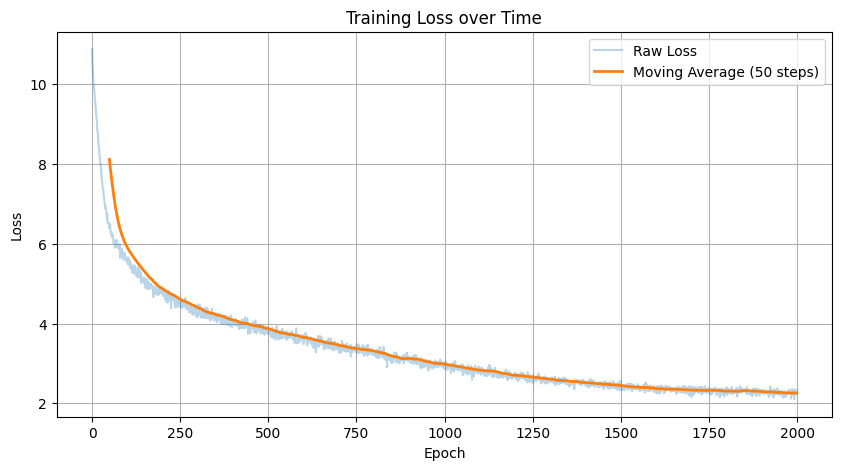

In [8]:
# ============================================================
# TODO: Train the Transformer
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Training Configuration
# ------------------------------------------------------------

NUM_EPOCHS = 2000
LEARNING_RATE = 3e-4
EVAL_INTERVAL = 50

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = model.to(device)


# ------------------------------------------------------------
# Optimizer and Scheduler
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Cosine annealing learning rate schedule
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-5
)


# ------------------------------------------------------------
# Training Loop
# ------------------------------------------------------------

model.train()
losses = []

for epoch in range(NUM_EPOCHS):

    # --------------------------------------------------------
    # Get batch
    # --------------------------------------------------------
    xb, yb = get_batch()
    xb, yb = xb.to(device), yb.to(device)

    # --------------------------------------------------------
    # Forward pass
    # --------------------------------------------------------
    logits = model(xb)          # (B, T, V)

    # --------------------------------------------------------
    # Compute loss
    # --------------------------------------------------------
    B, T, V = logits.shape

    logits_flat = logits.view(B * T, V)   # (B*T, V)
    targets_flat = yb.view(B * T)         # (B*T)

    loss = F.cross_entropy(logits_flat, targets_flat)

    # --------------------------------------------------------
    # Backward pass
    # --------------------------------------------------------
    optimizer.zero_grad()
    loss.backward()

    # Gradient clipping for stability
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()
    scheduler.step()

    # --------------------------------------------------------
    # Logging
    # --------------------------------------------------------
    losses.append(loss.item())

    if (epoch + 1) % EVAL_INTERVAL == 0:
        avg_loss = np.mean(losses[-EVAL_INTERVAL:])
        print(
            f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
            f"Loss: {loss.item():.4f} | "
            f"Avg Loss: {avg_loss:.4f}"
        )


print(f"\nTraining complete! Final loss: {losses[-1]:.4f}")


# ------------------------------------------------------------
# Plot Training Curve
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(losses, alpha=0.3, label="Raw Loss")

# Moving average for smoother visualization
window = 50
moving_avg = np.convolve(
    losses,
    np.ones(window) / window,
    mode="valid"
)

plt.plot(
    range(window - 1, len(losses)),
    moving_avg,
    linewidth=2,
    label="Moving Average (50 steps)"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Time")
plt.legend()
plt.grid(True)
plt.show()

## Autoregressive Text Generation Using MiniLM

After training, the Transformer can be used to generate text by predicting one token at a time. This process is called **autoregressive generation**, where the model repeatedly uses its previous predictions as input to generate new tokens.

At each step:

1. The current sequence of tokens is passed through the model.
2. The model produces probabilities for the next token.
3. A token is sampled from this probability distribution.
4. The sampled token is appended to the sequence.
5. The process repeats until the desired number of tokens has been generated.

Since the model was trained for next-token prediction, generation follows the same principle used during training, but now the predictions are fed back into the model.


Once the model has been trained, text can be generated by providing an initial prompt. The prompt is first tokenized, passed into the model, and the generated tokens are decoded back into text.

In [9]:
prompt = "The night was quiet and"
idxs = torch.tensor(encoder.encode(prompt)).unsqueeze(0).to(device)

model.eval()
generated_ids = model.generate(idxs, max_new_tokens=100)

generated_text = encoder.decode(generated_ids[0].tolist())
print(generated_text)


The night was quiet and _un strandsor_ers 'But the
decide a piano-key sank into the shadow of a sly--a,
the window--and used to pill exceedingly well, I had contemplated at
n't done. She was holding in hesitation and had was, at a pang I
from what I felt ashamed and notices the stuffingless, anything. She
before him. At that any way he had arrived, discoveries round. The longed words


As you can see, your model is far more superior than anything OpenAI has launched in the market. Answer the following questions based on your generated output:

1. **Quality of Generation**  
   Identify two things your model does well and two things it struggles with in the generated text. Explain why these behaviors occur in small Transformer models.

- The model produces locally fluent text, such as grammatically correct phrases and reasonable punctuation, because Transformers are good at learning short-range token dependencies. It can also imitate the general style of the training data. However, it struggles with long-term coherence and semantic consistency, often repeating phrases or drifting into nonsense. This happens because small Transformer models have limited capacity and cannot effectively model long-range context.


2. **Effect of Model and Data Limitations**  
   How do the size of the dataset and the size of the model (number of layers, embedding dimension, etc.) influence the quality and coherence of the generated text?

- A small dataset limits the diversity of language patterns the model can learn, leading to repetitive or shallow text generation. Similarly, a small model with fewer layers and smaller embedding dimensions has limited representational power. Together, these constraints prevent the model from learning deep semantic relationships, resulting in text that may look fluent but lacks coherence.

3. **Training vs Generation Quality**  
   Even if the training loss decreases over time, the generated text may still lack meaning. Explain why lower loss does not always correspond to better or more coherent text generation.

- Training loss measures how well the model predicts the next token, not whether the generated text is meaningful as a whole. During generation, the model relies on its own previous predictions, causing errors to accumulate over time. As a result, even with low training loss, the generated text may still lack coherence and overall meaning.


## Task 2 — Understanding Transformer Attention

So far in this assignment, you have implemented a Transformer from scratch. In this section, we move one step deeper and examine **what happens inside a Transformer during inference**.

One of the defining features of Transformers is the **attention mechanism**, which allows each token in a sequence to dynamically focus on other tokens when forming its representation.

Recall that in self-attention, each token computes attention scores with respect to every other token in the sequence:

$$
\text{Attention}(Q, K, V) =
\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

The resulting attention weights describe **how strongly one token attends to another**. These weights can be interpreted as a form of learned relationship between tokens.

For example, in the sentence:
"The scientist who discovered radium won a Nobel Prize."


the token *"who"* may attend strongly to *"scientist"*, indicating a grammatical relationship.

---

### Why Analyze Attention?

Attention analysis helps answer questions such as:

- Which words influence each other during processing?
- Do different attention heads learn different patterns?
- Does attention focus locally (nearby words) or globally (long-range dependencies)?

In research and industry, attention visualization is often used to:

- debug model behavior,
- study linguistic patterns learned by models,
- interpret model decisions,
- understand failure cases.

It is important to note that attention weights are **not perfect explanations**, but they provide useful insight into how Transformers distribute focus across tokens.

In this task, you will extract and analyze attention weights from a pretrained Transformer model to better understand how attention operates in practice.


### The Task
In this task, you will analyze attention patterns from a pretrained Transformer model. Instead of generating or classifying text, your goal is to **inspect and interpret the internal attention behavior** of the model.

This task is more algorithmic than previous tasks and requires working directly with model outputs.

---

### Objective

You will:

1. Load a pretrained Transformer model that exposes attention weights.
2. Pass input sentences through the model.
3. Extract attention matrices from one or more layers.
4. Visualize attention patterns using heatmaps.
5. Analyze how attention is distributed across tokens.

In [10]:
ATTENTION_TEST_SENTENCES = [
    "The scientist who discovered radium won a Nobel Prize.",
    "The dog chased the cat because it was scared.",
    "Artificial intelligence is transforming modern industries.",
    "The book that the professor recommended was difficult to understand."
]

Loading model with attention outputs...


BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Model loaded successfully!

Sentence 1:
The scientist who discovered radium won a Nobel Prize.

Tokens:
['[CLS]', 'the', 'scientist', 'who', 'discovered', 'ra', '##dium', 'won', 'a', 'nobel', 'prize', '.', '[SEP]']



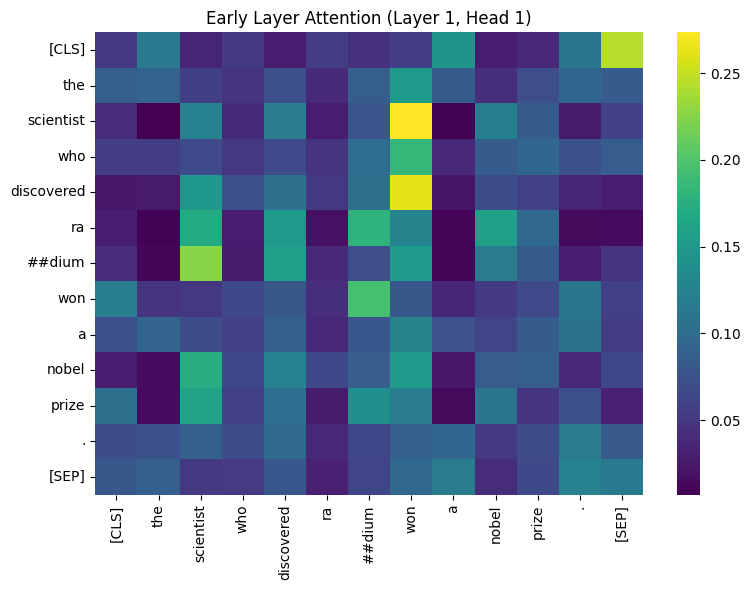

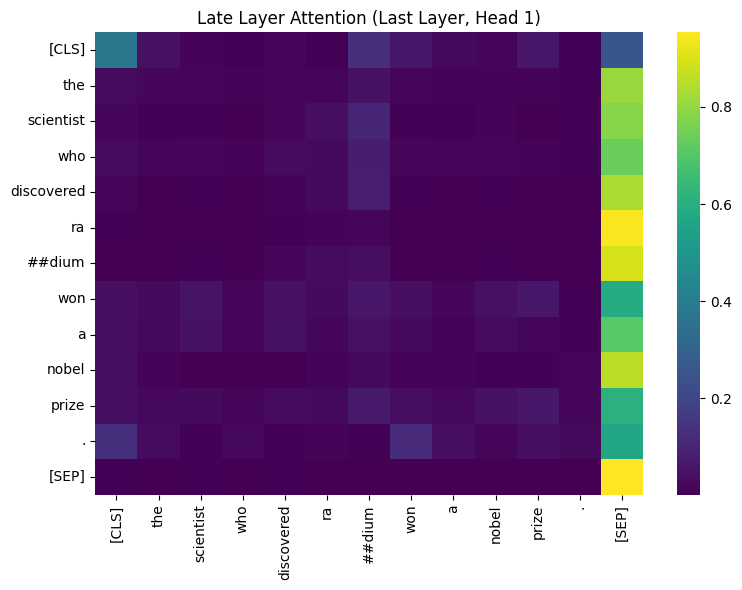

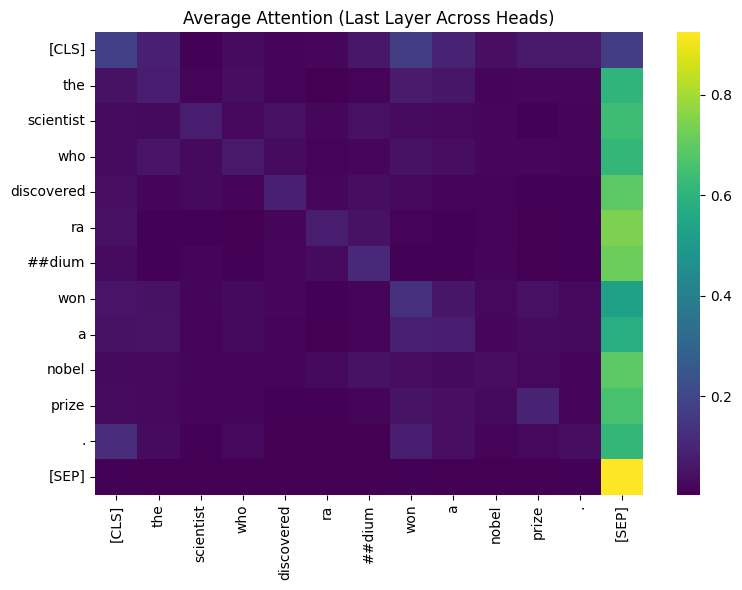

Sentence 2:
The dog chased the cat because it was scared.

Tokens:
['[CLS]', 'the', 'dog', 'chased', 'the', 'cat', 'because', 'it', 'was', 'scared', '.', '[SEP]']



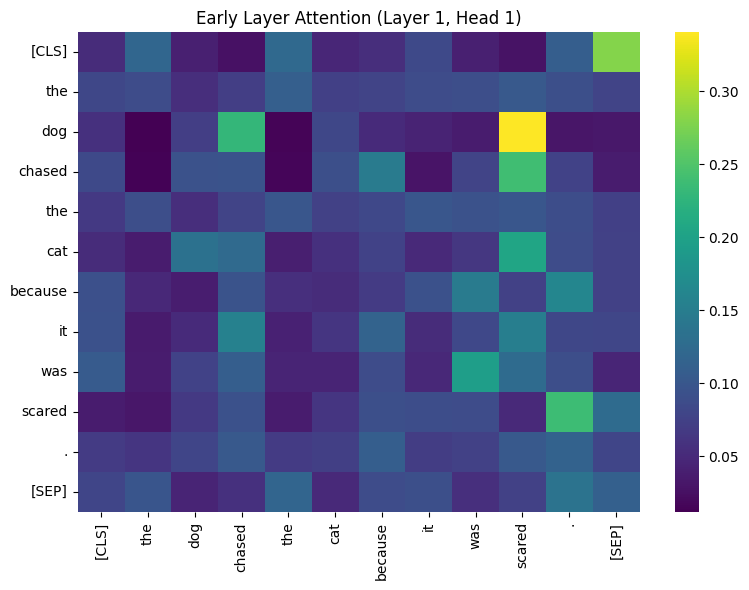

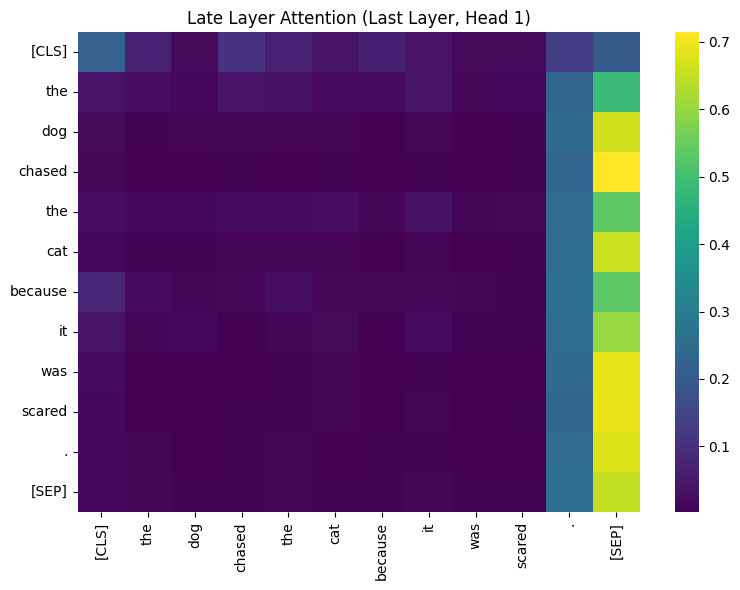

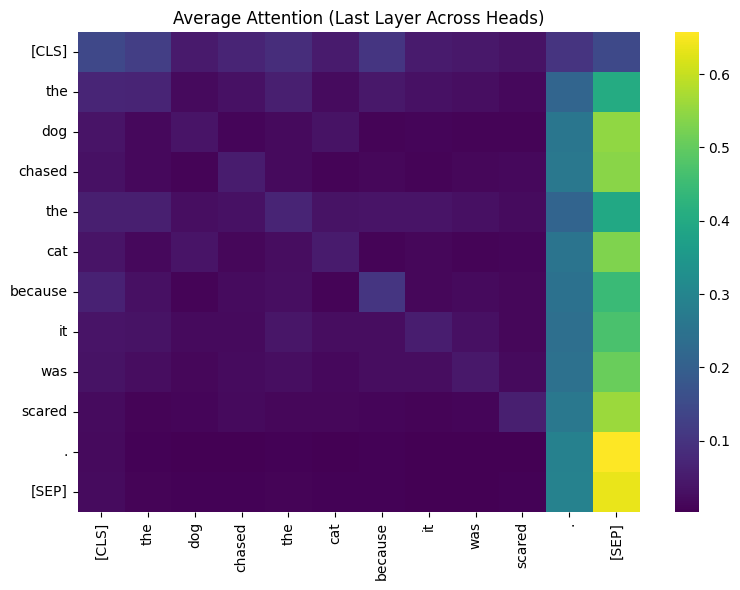

Sentence 3:
Artificial intelligence is transforming modern industries.

Tokens:
['[CLS]', 'artificial', 'intelligence', 'is', 'transforming', 'modern', 'industries', '.', '[SEP]']



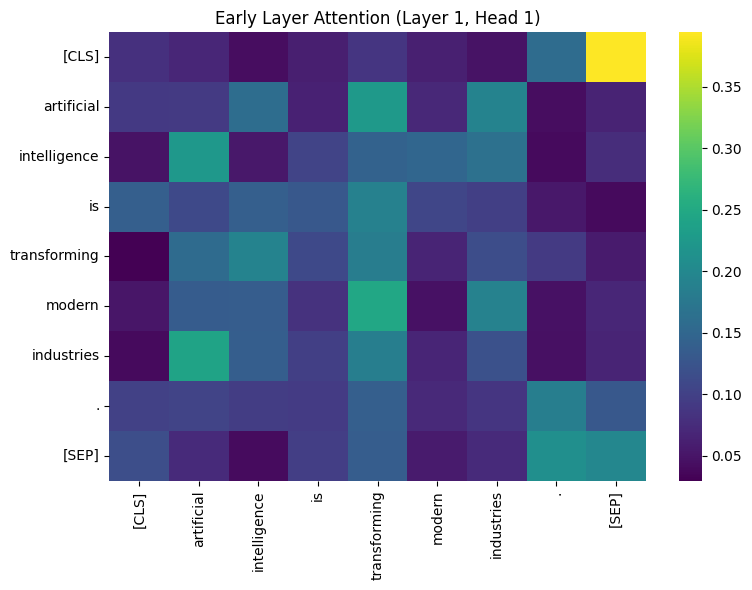

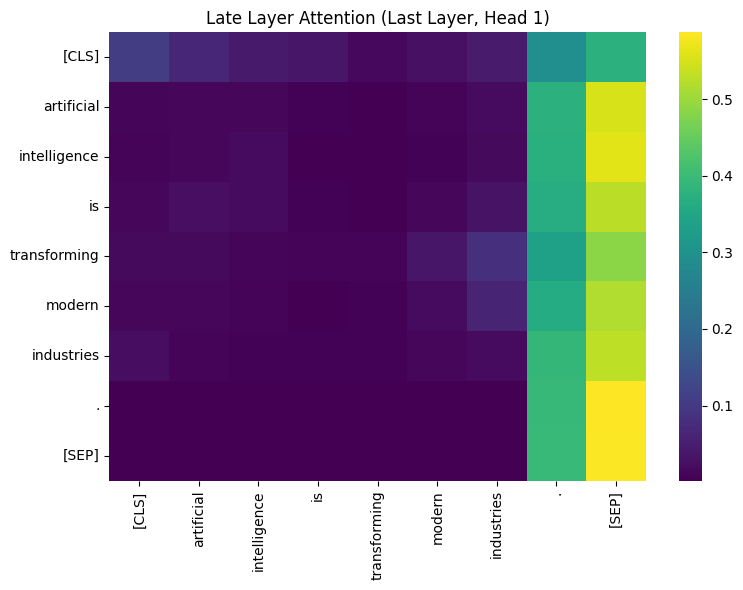

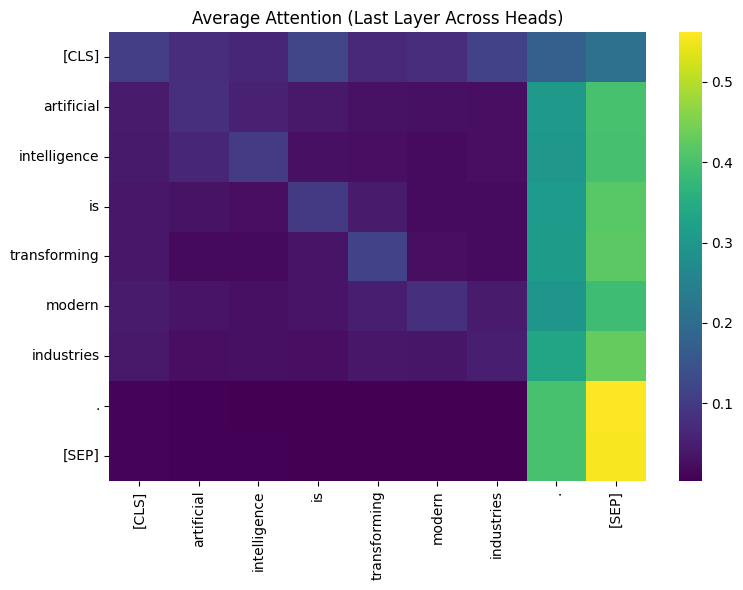

Sentence 4:
The book that the professor recommended was difficult to understand.

Tokens:
['[CLS]', 'the', 'book', 'that', 'the', 'professor', 'recommended', 'was', 'difficult', 'to', 'understand', '.', '[SEP]']



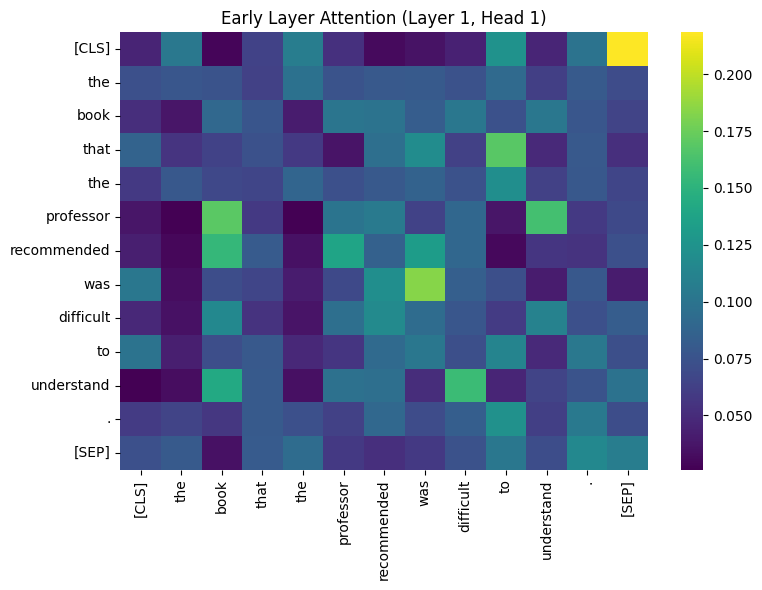

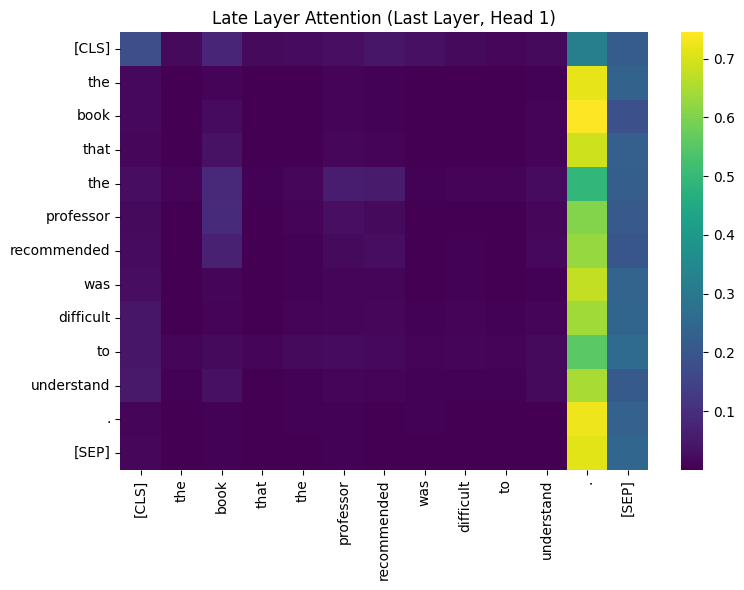

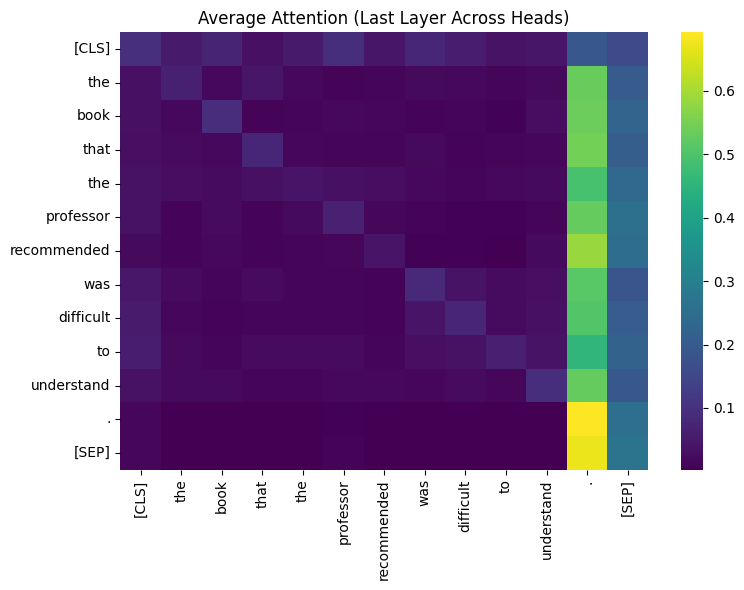

In [11]:
# ============================================================
# Attention Analysis — Solution Code
# ============================================================

import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModel


# ------------------------------------------------------------
# Load Pretrained Model with Attention Outputs
# ------------------------------------------------------------

MODEL_NAME = "bert-base-uncased"

print("Loading model with attention outputs...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModel.from_pretrained(
    MODEL_NAME,
    output_attentions=True
)

model.eval()
print("Model loaded successfully!\n")

# ------------------------------------------------------------
# Helper Function: Plot Attention Heatmap
# ------------------------------------------------------------

def plot_attention(attention_matrix, tokens, title):

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        attention_matrix,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="viridis"
    )

    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Attention Analysis Loop
# ------------------------------------------------------------

for sentence_id, sentence in enumerate(ATTENTION_TEST_SENTENCES, 1):

    print("=" * 80)
    print(f"Sentence {sentence_id}:")
    print(sentence)
    print()

    # Tokenize input
    inputs = tokenizer(sentence, return_tensors="pt")

    # Forward pass
    with torch.no_grad():
        outputs = model(**inputs)

    attentions = outputs.attentions
    # tuple of length = num_layers

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    print("Tokens:")
    print(tokens)
    print()

    # --------------------------------------------------------
    # Example 1: Early Layer Attention (Layer 1, Head 0)
    # --------------------------------------------------------

    early_attention = attentions[0][0, 0].cpu().numpy()
    plot_attention(
        early_attention,
        tokens,
        title="Early Layer Attention (Layer 1, Head 1)"
    )

    # --------------------------------------------------------
    # Example 2: Late Layer Attention (Last Layer, Head 0)
    # --------------------------------------------------------

    late_attention = attentions[-1][0, 0].cpu().numpy()
    plot_attention(
        late_attention,
        tokens,
        title="Late Layer Attention (Last Layer, Head 1)"
    )

    # --------------------------------------------------------
    # Example 3: Average Attention Across Heads
    # --------------------------------------------------------

    avg_attention = attentions[-1][0].mean(dim=0).cpu().numpy()

    plot_attention(
        avg_attention,
        tokens,
        title="Average Attention (Last Layer Across Heads)"
    )


Answer the following questions based on the attention visualizations and observations from this task:

1. **Layer-wise Attention Behavior**  
   Compare the attention patterns from early layers and later layers. Do earlier layers focus more on nearby tokens while later layers capture longer-range relationships? Provide examples from the heatmaps to support your answer.

- In earlier layers, attention tends to focus on nearby or adjacent tokens, indicating that these layers capture local syntactic relationships such as word order or short phrases. In contrast, later layers often attend to tokens that are farther apart, reflecting longer-range dependencies like sentence structure or semantic relationships. This progression is visible in the heatmaps, where early layers show attention concentrated near the diagonal, while later layers show more dispersed patterns.

2. **Attention Head Specialization**  
   Do different attention heads appear to focus on different tokens or relationships within the same sentence? Describe any patterns you observe and explain why multiple attention heads might be useful.

- Different attention heads within the same layer often focus on different aspects of the input, such as punctuation, specific keywords, or positional relationships. Some heads may attend strongly to the previous token, while others focus on structurally important words. Multiple heads are useful because they allow the model to capture multiple relationships in parallel, increasing representational richness.

3. **Interpretation of Attention**  
   Are tokens always attending most strongly to semantically related words? Identify at least one example where attention appears unintuitive or difficult to interpret. What does this suggest about using attention as an explanation for model behavior?

- Tokens do not always attend most strongly to semantically related words; in some cases, attention focuses on punctuation, stop words, or seemingly unrelated tokens. These unintuitive patterns suggest that attention weights may encode structural or positional information rather than meaning alone. This highlights that attention should not always be treated as a direct or complete explanation of model reasoning.

4. **Comparison with Your Transformer Implementation**  
   Based on your own Transformer implementation earlier in the assignment, explain how the attention mechanism used here is similar or different. Why might pretrained models exhibit clearer or more structured attention patterns?

- The attention mechanism in this task is structurally similar to the one implemented earlier, using scaled dot-product attention with multiple heads. However, pretrained models show clearer and more structured attention patterns because they are trained on much larger datasets with deeper architectures. This extensive training allows attention heads to specialize and learn more interpretable patterns over time.


# Task 3: Applications of Pretrained Transformers
In the previous sections, you implemented and trained a Transformer model from scratch. While this helps understand how Transformers work internally, real-world NLP systems rarely train models from zero. Instead, practitioners rely on **pretrained Transformer models** that have already learned general language representations from massive datasets.

In this task, you will explore how pretrained Transformer models are used for **language understanding tasks**, rather than text generation.

Unlike your MiniGPT model (which is decoder-only and designed for generation), the models used here are **encoder-based Transformers**, optimized for understanding and analyzing text.

You will complete two industry-style tasks:

1. Zero-Shot Text Classification  
2. Part-of-Speech (POS) Tagging

## Part A — Zero-Shot Text Classification

### What is Zero-Shot Classification?

Zero-shot classification is a technique where a model assigns labels to text **without being explicitly trained on those specific labels beforehand**. Instead of learning a fixed set of categories during training, the model relies on its general language understanding to determine which label best matches the input.

For example:
Text: "The stock market crashed today."
Labels: ["finance", "sports", "politics"]
Output: finance


This ability comes from large-scale pretraining, where the model learns relationships between language concepts and can generalize to new tasks at inference time.

Zero-shot classification is widely used in industry for:

- automatic content tagging,
- moderation systems,
- routing user queries,
- organizing large document collections.

Unlike the Transformer you built earlier, which generates text autoregressively, zero-shot classification focuses on **understanding and categorizing text**.

---

### Your Task

In this section, you will use a pretrained Transformer model to classify sentences into categories without additional training.

You are required to:

1. Load a pretrained zero-shot classification model from HuggingFace.
2. Apply the model to all provided test sentences.
3. Predict the most suitable label from the candidate label set.
4. Report the predicted label along with the confidence score.

In [12]:
# ------------------------------------------------------------
# Mandatory Test Sentences (Do Not Modify)
# ------------------------------------------------------------

ZERO_SHOT_SENTENCES = [
    "The government announced new economic reforms today.",
    "The team scored a last-minute goal to win the championship.",
    "Researchers developed a new AI model for medical diagnosis.",
    "The company reported record profits this quarter.",
    "A new smartphone was launched with improved battery life."
]
CANDIDATE_LABELS = ["politics", "sports", "technology", "business"]

In [13]:
# ============================================================
# Zero-Shot Text Classification — Solution Code
# ============================================================

from transformers import pipeline

# ------------------------------------------------------------
# Load Pretrained Zero-Shot Classification Model
# ------------------------------------------------------------

print("Loading zero-shot classification model...")
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)
print("Model loaded successfully!\n")

# ------------------------------------------------------------
# Run Zero-Shot Classification
# ------------------------------------------------------------

print("=" * 80)

for idx, sentence in enumerate(ZERO_SHOT_SENTENCES, 1):

    print(f"\nSentence {idx}:")
    print(f'"{sentence}"\n')

    result = classifier(sentence, CANDIDATE_LABELS)

    print("Predicted Label:")
    print(f"  → {result['labels'][0]} "
          f"(confidence: {result['scores'][0]:.3f})")

    print("\nAll Label Scores:")
    for label, score in zip(result["labels"], result["scores"]):
        print(f"  {label:12s}: {score:.3f}")

print("\n" + "=" * 80)
print("Zero-Shot Classification Complete!")


Loading zero-shot classification model...


config.json: 0.00B [00:00, ?B/s]

C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\pc\.cache\huggingface\hub\models--facebook--bart-large-mnli. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular H

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Model loaded successfully!


Sentence 1:
"The government announced new economic reforms today."

Predicted Label:
  → business (confidence: 0.523)

All Label Scores:
  business    : 0.523
  politics    : 0.322
  technology  : 0.101
  sports      : 0.054

Sentence 2:
"The team scored a last-minute goal to win the championship."

Predicted Label:
  → sports (confidence: 0.922)

All Label Scores:
  sports      : 0.922
  technology  : 0.044
  business    : 0.026
  politics    : 0.009

Sentence 3:
"Researchers developed a new AI model for medical diagnosis."

Predicted Label:
  → technology (confidence: 0.988)

All Label Scores:
  technology  : 0.988
  business    : 0.006
  sports      : 0.003
  politics    : 0.002

Sentence 4:
"The company reported record profits this quarter."

Predicted Label:
  → business (confidence: 0.972)

All Label Scores:
  business    : 0.972
  technology  : 0.019
  sports      : 0.005
  politics    : 0.004

Sentence 5:
"A new smartphone was launched with improved

## Part B — Part-of-Speech (POS) Tagging

### What is Part-of-Speech Tagging?

Part-of-Speech (POS) tagging is the task of assigning a grammatical label to each word in a sentence based on its role in the sentence. Common POS categories include:

- **NOUN** — people, places, or things  
- **VERB** — actions or states  
- **ADJ** — descriptive words  
- **ADV** — modifiers of verbs or adjectives  
- **DET** — determiners (e.g., *the*, *a*)  
- **PRON** — pronouns  
- and other grammatical categories.

For example:
"The dog runs fast"
The (DET) dog (NOUN) runs (VERB) fast (ADV)

Unlike zero-shot classification, which assigns a single label to an entire sentence, POS tagging operates at the **token level**, predicting labels for individual words. This makes it a fundamental task for many language understanding systems.

POS tagging is commonly used in industry for:

- grammar and writing assistance tools,
- syntactic parsing,
- speech and language processing,
- information extraction pipelines.

---

### Your Task

In this section, you will use a pretrained Transformer model to assign part-of-speech tags to words in a sentence.

You are required to:

1. Load a pretrained POS tagging model from HuggingFace.
2. Apply the model to all provided test sentences.
3. Display each detected token along with its predicted POS tag.
4. Observe how the model handles punctuation, proper nouns, and ambiguous words.



In [14]:
POS_TEST_SENTENCES = [
    "The quick brown fox jumps over the lazy dog.",
    "Marie Curie conducted pioneering research in radioactivity.",
    "Artificial intelligence is transforming modern industries.",
    "The students submitted their assignments before midnight.",
    "She carefully analyzed the experimental results."
]

In [15]:
# ============================================================
# Part-of-Speech (POS) Tagging — Solution Code
# ============================================================

from transformers import pipeline

# ------------------------------------------------------------
# Load Pretrained POS Tagging Model
# ------------------------------------------------------------

print("Loading POS tagging model...")
pos_tagger = pipeline(
    "token-classification",
    model="vblagoje/bert-english-uncased-finetuned-pos",
    aggregation_strategy="simple"
)
print("Model loaded successfully!\n")


# ------------------------------------------------------------
# Run POS Tagging
# ------------------------------------------------------------

print("=" * 80)

for idx, sentence in enumerate(POS_TEST_SENTENCES, 1):

    print(f"\nSentence {idx}:")
    print(f'"{sentence}"\n')

    outputs = pos_tagger(sentence)

    print("Token-Level POS Tags:")
    for token in outputs:
        word = token["word"]
        label = token["entity_group"]
        confidence = token["score"]

        print(f"  {word:15s} → {label} (confidence: {confidence:.2f})")

print("\n" + "=" * 80)
print("POS Tagging Complete!")


Loading POS tagging model...


config.json: 0.00B [00:00, ?B/s]

C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\pc\.cache\huggingface\hub\models--vblagoje--bert-english-uncased-finetuned-pos. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Fallin

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of the model checkpoint at vblagoje/bert-english-uncased-finetuned-pos were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


Model loaded successfully!


Sentence 1:
"The quick brown fox jumps over the lazy dog."

Token-Level POS Tags:
  the             → DET (confidence: 1.00)
  quick brown     → ADJ (confidence: 0.97)
  fox             → NOUN (confidence: 1.00)
  jumps           → VERB (confidence: 1.00)
  over            → ADP (confidence: 1.00)
  the             → DET (confidence: 1.00)
  lazy            → ADJ (confidence: 1.00)
  dog             → NOUN (confidence: 1.00)
  .               → PUNCT (confidence: 1.00)

Sentence 2:
"Marie Curie conducted pioneering research in radioactivity."

Token-Level POS Tags:
  marie curie     → PROPN (confidence: 1.00)
  conducted       → VERB (confidence: 1.00)
  pioneering      → ADJ (confidence: 0.92)
  research        → NOUN (confidence: 1.00)
  in              → ADP (confidence: 1.00)
  radioactivity   → NOUN (confidence: 0.99)
  .               → PUNCT (confidence: 1.00)

Sentence 3:
"Artificial intelligence is transforming modern industries."

Token-Level POS 

Reference(s): https://machinelearningmastery.com/the-transformer-model/